In [283]:
import pandas as pd
import matplotlib.pyplot as plt

In [284]:
df = pd.read_csv("../data/raw/matches.csv")
df.head()

,key_id,tournament_id,tournament_name,match_id,match_name,stage_name,group_name,group_stage,knockout_stage,replayed,...,away_team_score_margin,extra_time,penalty_shootout,score_penalties,home_team_score_penalties,away_team_score_penalties,result,home_team_win,away_team_win,draw
0,1,WC-1930,1930 FIFA Men's World Cup,M-1930-01,France vs Mexico,group stage,Group 1,1,0,0,...,-3,0,0,0-0,0,0,home team win,1,0,0
1,2,WC-1930,1930 FIFA Men's World Cup,M-1930-02,United States vs Belgium,group stage,Group 4,1,0,0,...,-3,0,0,0-0,0,0,home team win,1,0,0
2,3,WC-1930,1930 FIFA Men's World Cup,M-1930-03,Yugoslavia vs Brazil,group stage,Group 2,1,0,0,...,-1,0,0,0-0,0,0,home team win,1,0,0
3,4,WC-1930,1930 FIFA Men's World Cup,M-1930-04,Romania vs Peru,group stage,Group 3,1,0,0,...,-2,0,0,0-0,0,0,home team win,1,0,0
4,5,WC-1930,1930 FIFA Men's World Cup,M-1930-05,Argentina vs France,group stage,Group 1,1,0,0,...,-1,0,0,0-0,0,0,home team win,1,0,0


In [285]:
print(f"Raw data shape: {df.shape}\n")
print(f"Columns: \n{df.columns}\n")
print(f"Misisng values: \n{df.isnull().sum()}")

Raw data shape: (1248, 37)

Columns: 
Index(['key_id', 'tournament_id', 'tournament_name', 'match_id', 'match_name',
       'stage_name', 'group_name', 'group_stage', 'knockout_stage', 'replayed',
       'replay', 'match_date', 'match_time', 'stadium_id', 'stadium_name',
       'city_name', 'country_name', 'home_team_id', 'home_team_name',
       'home_team_code', 'away_team_id', 'away_team_name', 'away_team_code',
       'score', 'home_team_score', 'away_team_score', 'home_team_score_margin',
       'away_team_score_margin', 'extra_time', 'penalty_shootout',
       'score_penalties', 'home_team_score_penalties',
       'away_team_score_penalties', 'result', 'home_team_win', 'away_team_win',
       'draw'],
      dtype='object')

Misisng values: 
key_id                       0
tournament_id                0
tournament_name              0
match_id                     0
match_name                   0
stage_name                   0
group_name                   0
group_stage               

In [286]:
# The card system was introduced in 1970; there was no such system prior to that, so we drop the previous tournaments

df["match_date"] = pd.to_datetime(df["match_date"])
df = df[df["match_date"].dt.year >= 1970]

# This work focuses on FIFA Men's World Cup only
df = df[df["tournament_name"].str.contains("Men's")]

print(f"Current data shape: {df.shape}")
df.head()

Current data shape: (764, 37)


,key_id,tournament_id,tournament_name,match_id,match_name,stage_name,group_name,group_stage,knockout_stage,replayed,...,away_team_score_margin,extra_time,penalty_shootout,score_penalties,home_team_score_penalties,away_team_score_penalties,result,home_team_win,away_team_win,draw
200,201,WC-1970,1970 FIFA Men's World Cup,M-1970-01,Mexico vs Soviet Union,group stage,Group 1,1,0,0,...,0,0,0,0-0,0,0,draw,0,0,1
201,202,WC-1970,1970 FIFA Men's World Cup,M-1970-02,Uruguay vs Israel,group stage,Group 2,1,0,0,...,-2,0,0,0-0,0,0,home team win,1,0,0
202,203,WC-1970,1970 FIFA Men's World Cup,M-1970-03,England vs Romania,group stage,Group 3,1,0,0,...,-1,0,0,0-0,0,0,home team win,1,0,0
203,204,WC-1970,1970 FIFA Men's World Cup,M-1970-04,Peru vs Bulgaria,group stage,Group 4,1,0,0,...,-1,0,0,0-0,0,0,home team win,1,0,0
204,205,WC-1970,1970 FIFA Men's World Cup,M-1970-05,Belgium vs El Salvador,group stage,Group 1,1,0,0,...,-3,0,0,0-0,0,0,home team win,1,0,0


In [287]:
# drop unused/irrelevant columns

df = df.drop(columns = ["key_id", "group_name", "match_time", "replay", "replayed", "country_name", "stadium_id", "stadium_name", "city_name",
                        "group_stage", "knockout_stage", "home_team_code", "away_team_code", 
                        "away_team_score_margin", "score_penalties"]).reset_index().drop(columns = "index")
print(f"Current data shape: {df.shape} \n")
print(f"Columns: {df.columns} \n")
df.head()

Current data shape: (764, 22) 

Columns: Index(['tournament_id', 'tournament_name', 'match_id', 'match_name',
       'stage_name', 'match_date', 'home_team_id', 'home_team_name',
       'away_team_id', 'away_team_name', 'score', 'home_team_score',
       'away_team_score', 'home_team_score_margin', 'extra_time',
       'penalty_shootout', 'home_team_score_penalties',
       'away_team_score_penalties', 'result', 'home_team_win', 'away_team_win',
       'draw'],
      dtype='object') 



,tournament_id,tournament_name,match_id,match_name,stage_name,match_date,home_team_id,home_team_name,away_team_id,away_team_name,...,away_team_score,home_team_score_margin,extra_time,penalty_shootout,home_team_score_penalties,away_team_score_penalties,result,home_team_win,away_team_win,draw
0,WC-1970,1970 FIFA Men's World Cup,M-1970-01,Mexico vs Soviet Union,group stage,1970-05-31,T-46,Mexico,T-72,Soviet Union,...,0,0,0,0,0,0,draw,0,0,1
1,WC-1970,1970 FIFA Men's World Cup,M-1970-02,Uruguay vs Israel,group stage,1970-06-02,T-84,Uruguay,T-40,Israel,...,0,2,0,0,0,0,home team win,1,0,0
2,WC-1970,1970 FIFA Men's World Cup,M-1970-03,England vs Romania,group stage,1970-06-02,T-28,England,T-61,Romania,...,0,1,0,0,0,0,home team win,1,0,0
3,WC-1970,1970 FIFA Men's World Cup,M-1970-04,Peru vs Bulgaria,group stage,1970-06-02,T-56,Peru,T-10,Bulgaria,...,2,1,0,0,0,0,home team win,1,0,0
4,WC-1970,1970 FIFA Men's World Cup,M-1970-05,Belgium vs El Salvador,group stage,1970-06-03,T-06,Belgium,T-27,El Salvador,...,0,3,0,0,0,0,home team win,1,0,0


In [288]:
# load the team dataset

df_teams = pd.read_csv("../data/raw/teams.csv")
df_teams.head()

,key_id,team_id,team_name,team_code,mens_team,womens_team,federation_name,region_name,confederation_id,confederation_name,confederation_code,mens_team_wikipedia_link,womens_team_wikipedia_link,federation_wikipedia_link
0,1,T-01,Algeria,DZA,1,0,Algerian Football Federation,Africa,CF-2,Confederation of African Football,CAF,https://en.wikipedia.org/wiki/Algeria_national...,not applicable,https://en.wikipedia.org/wiki/Algerian_Footbal...
1,2,T-02,Angola,AGO,1,0,Angolan Football Federation,Africa,CF-2,Confederation of African Football,CAF,https://en.wikipedia.org/wiki/Angola_national_...,not applicable,https://en.wikipedia.org/wiki/Angolan_Football...
2,3,T-03,Argentina,ARG,1,1,Argentine Football Association,South America,CF-4,South American Football Confederation,CONMEBOL,https://en.wikipedia.org/wiki/Argentina_nation...,https://en.wikipedia.org/wiki/Argentina_women'...,https://en.wikipedia.org/wiki/Argentine_Footba...
3,4,T-04,Australia,AUS,1,1,Football Australia,Oceania,CF-1,Asian Football Confederation,AFC,https://en.wikipedia.org/wiki/Australia_men%27...,https://en.wikipedia.org/wiki/Australia_women'...,https://en.wikipedia.org/wiki/Football_Australia
4,5,T-05,Austria,AUT,1,0,Austrian Football Association,Europe,CF-6,Union of European Football Associations,UEFA,https://en.wikipedia.org/wiki/Austria_national...,not applicable,https://en.wikipedia.org/wiki/Austrian_Footbal...


In [289]:
df_teams = df_teams[["team_id", "team_name", "confederation_code"]]
df_teams

,team_id,team_name,confederation_code
0,T-01,Algeria,CAF
1,T-02,Angola,CAF
2,T-03,Argentina,CONMEBOL
3,T-04,Australia,AFC
4,T-05,Austria,UEFA
...,...,...,...
83,T-84,Uruguay,CONMEBOL
84,T-85,Wales,UEFA
85,T-86,West Germany,UEFA
86,T-87,Yugoslavia,UEFA


In [290]:
df = df.merge(df_teams.rename(columns = {"team_id": "home_team_id"}), 
              on = "home_team_id", 
              how = "left").rename(columns = {"confederation_code": "home_team_confederation"}).drop(columns = "team_name")

df = df.merge(df_teams.rename(columns = {"team_id": "away_team_id"}), 
              on = "away_team_id", 
              how = "left").rename(columns = {"confederation_code": "away_team_confederation"}).drop(columns = "team_name")

In [291]:
print(f"Current columns: {df.columns} \n")

order = ['tournament_id', 'tournament_name', 'match_id', 'match_name',
       'stage_name', 'match_date', 'home_team_id', 'home_team_name',
       'home_team_confederation', 'away_team_id', 'away_team_confederation', 'away_team_name',
       'score', 'home_team_score', 'away_team_score', "home_team_score_margin",  'extra_time', 'penalty_shootout',
       'home_team_score_penalties', 'away_team_score_penalties', 'result',
       'home_team_win', 'away_team_win', 'draw']
df = df.reindex(columns = order)
print("Reset column order:")
df.head()

Current columns: Index(['tournament_id', 'tournament_name', 'match_id', 'match_name',
       'stage_name', 'match_date', 'home_team_id', 'home_team_name',
       'away_team_id', 'away_team_name', 'score', 'home_team_score',
       'away_team_score', 'home_team_score_margin', 'extra_time',
       'penalty_shootout', 'home_team_score_penalties',
       'away_team_score_penalties', 'result', 'home_team_win', 'away_team_win',
       'draw', 'home_team_confederation', 'away_team_confederation'],
      dtype='object') 

Reset column order:


,tournament_id,tournament_name,match_id,match_name,stage_name,match_date,home_team_id,home_team_name,home_team_confederation,away_team_id,...,away_team_score,home_team_score_margin,extra_time,penalty_shootout,home_team_score_penalties,away_team_score_penalties,result,home_team_win,away_team_win,draw
0,WC-1970,1970 FIFA Men's World Cup,M-1970-01,Mexico vs Soviet Union,group stage,1970-05-31,T-46,Mexico,CONCACAF,T-72,...,0,0,0,0,0,0,draw,0,0,1
1,WC-1970,1970 FIFA Men's World Cup,M-1970-02,Uruguay vs Israel,group stage,1970-06-02,T-84,Uruguay,CONMEBOL,T-40,...,0,2,0,0,0,0,home team win,1,0,0
2,WC-1970,1970 FIFA Men's World Cup,M-1970-03,England vs Romania,group stage,1970-06-02,T-28,England,UEFA,T-61,...,0,1,0,0,0,0,home team win,1,0,0
3,WC-1970,1970 FIFA Men's World Cup,M-1970-04,Peru vs Bulgaria,group stage,1970-06-02,T-56,Peru,CONMEBOL,T-10,...,2,1,0,0,0,0,home team win,1,0,0
4,WC-1970,1970 FIFA Men's World Cup,M-1970-05,Belgium vs El Salvador,group stage,1970-06-03,T-06,Belgium,UEFA,T-27,...,0,3,0,0,0,0,home team win,1,0,0


In [292]:
home_team = list(df["home_team_name"].unique())
print(f"Number of unique home teams: {len(home_team)}")
print(f"Example teams: {home_team[0:5]} \n")

away_team = list(df["away_team_name"].unique())
print(f"Number of unique away teams: {len(away_team)}")
print(f"Example teams: {away_team[0:5]}")

Number of unique home teams: 80
Example teams: ['Mexico', 'Uruguay', 'England', 'Peru', 'Belgium'] 

Number of unique away teams: 83
Example teams: ['Soviet Union', 'Israel', 'Romania', 'Bulgaria', 'El Salvador']


In [293]:
all_team = list(set(home_team + away_team))
print(f"Number of unique teams since World Cup 1970: {len(all_team)}")
print(f"Example teams: {all_team[0:5]}")

Number of unique teams since World Cup 1970: 83
Example teams: ['Australia', 'Germany', 'Japan', 'England', 'Bulgaria']


In [308]:
unique_team = pd.DataFrame({"team_name": all_team}).merge(df_teams, on = "team_name", how = "left")
unique_team

,team_name,team_id,confederation_code
0,Australia,T-04,AFC
1,Germany,T-31,UEFA
2,Japan,T-44,AFC
3,England,T-28,UEFA
4,Bulgaria,T-10,UEFA
...,...,...,...
78,Switzerland,T-75,UEFA
79,Czechoslovakia,T-21,UEFA
80,Spain,T-73,UEFA
81,France,T-30,UEFA


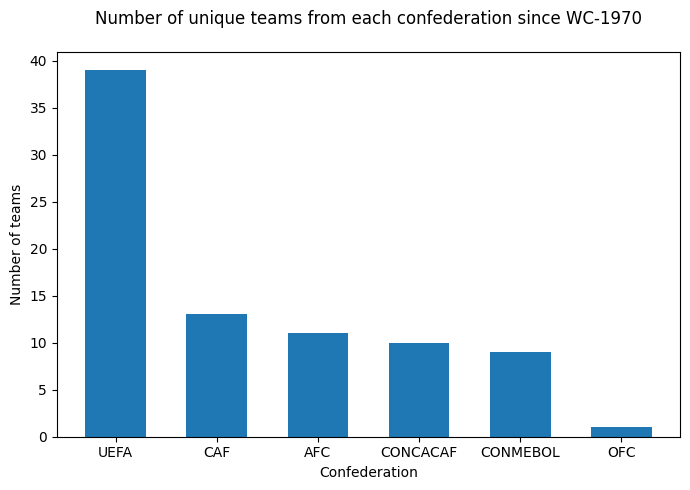

In [314]:
plt.figure(figsize = (7, 5)) 

plt.bar(
    x = pd.DataFrame(unique_team["confederation_code"].value_counts()).reset_index()["confederation_code"],
    height = pd.DataFrame(unique_team["confederation_code"].value_counts()).reset_index()["count"],
    width = 0.6
)

plt.ylabel("Number of teams")
plt.xlabel("Confederation")
plt.title("Number of unique teams from each confederation since WC-1970", y = 1.05)
plt.tight_layout()

In [315]:
(df["extra_time"] == 1).mean()

np.float64(0.07722513089005235)

In [316]:
df_knockout = df[df["stage_name"] != "group stage"]

In [317]:
df_knockout

,tournament_id,tournament_name,match_id,match_name,stage_name,match_date,home_team_id,home_team_name,home_team_confederation,away_team_id,...,away_team_score,home_team_score_margin,extra_time,penalty_shootout,home_team_score_penalties,away_team_score_penalties,result,home_team_win,away_team_win,draw
24,WC-1970,1970 FIFA Men's World Cup,M-1970-25,Brazil vs Peru,quarter-finals,1970-06-14,T-09,Brazil,CONMEBOL,T-56,...,2,2,0,0,0,0,home team win,1,0,0
25,WC-1970,1970 FIFA Men's World Cup,M-1970-26,Italy vs Mexico,quarter-finals,1970-06-14,T-41,Italy,UEFA,T-46,...,1,3,0,0,0,0,home team win,1,0,0
26,WC-1970,1970 FIFA Men's World Cup,M-1970-27,Soviet Union vs Uruguay,quarter-finals,1970-06-14,T-72,Soviet Union,UEFA,T-84,...,1,-1,1,0,0,0,away team win,0,1,0
27,WC-1970,1970 FIFA Men's World Cup,M-1970-28,West Germany vs England,quarter-finals,1970-06-14,T-86,West Germany,UEFA,T-28,...,2,1,1,0,0,0,home team win,1,0,0
28,WC-1970,1970 FIFA Men's World Cup,M-1970-29,Brazil vs Uruguay,semi-finals,1970-06-17,T-09,Brazil,CONMEBOL,T-84,...,1,2,0,0,0,0,home team win,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
759,WC-2022,2022 FIFA Men's World Cup,M-2022-60,England vs France,quarter-finals,2022-12-10,T-28,England,UEFA,T-30,...,2,-1,0,0,0,0,away team win,0,1,0
760,WC-2022,2022 FIFA Men's World Cup,M-2022-61,Argentina vs Croatia,semi-finals,2022-12-13,T-03,Argentina,CONMEBOL,T-18,...,0,3,0,0,0,0,home team win,1,0,0
761,WC-2022,2022 FIFA Men's World Cup,M-2022-62,France vs Morocco,semi-finals,2022-12-14,T-30,France,UEFA,T-47,...,0,2,0,0,0,0,home team win,1,0,0
762,WC-2022,2022 FIFA Men's World Cup,M-2022-63,Croatia vs Morocco,third-place match,2022-12-17,T-18,Croatia,UEFA,T-47,...,1,1,0,0,0,0,home team win,1,0,0
